## Social Network Analysis of Facebook Graph Data

### Project Summary
This project explores structural properties of a large social network using the Facebook Combined Network dataset from the Stanford SNAP repository. Using graph analytics techniques, the analysis investigates network density, degree distributions, centrality measures, community structure, and link prediction methods.

### Goals
- Analyze structural properties of a real-world social network graph
- Investigate whether the network follows a power-law degree distribution
- Identify influential nodes using centrality metrics
- Detect communities within the network
- Evaluate link prediction methods for predicting missing connections

## Install libraries
Note: Feel free to install necessry libraries if needed

In [ ]:
# Install required packages
!pip install -q networkx matplotlib numpy pandas seaborn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Import libraries

In [ ]:
import requests
import gzip
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random

## Load the graph

In [ ]:
url = "https://snap.stanford.edu/data/facebook_combined.txt.gz"

response = requests.get(url, stream=True)
response.raise_for_status()

with gzip.GzipFile(fileobj=response.raw) as f:
    G = nx.read_edgelist(f, nodetype=int)

## Some initialization

In [ ]:
plt.rcParams["figure.figsize"] = (7,7)
random.seed(42)

### Visualization (Sampled Subgraph)

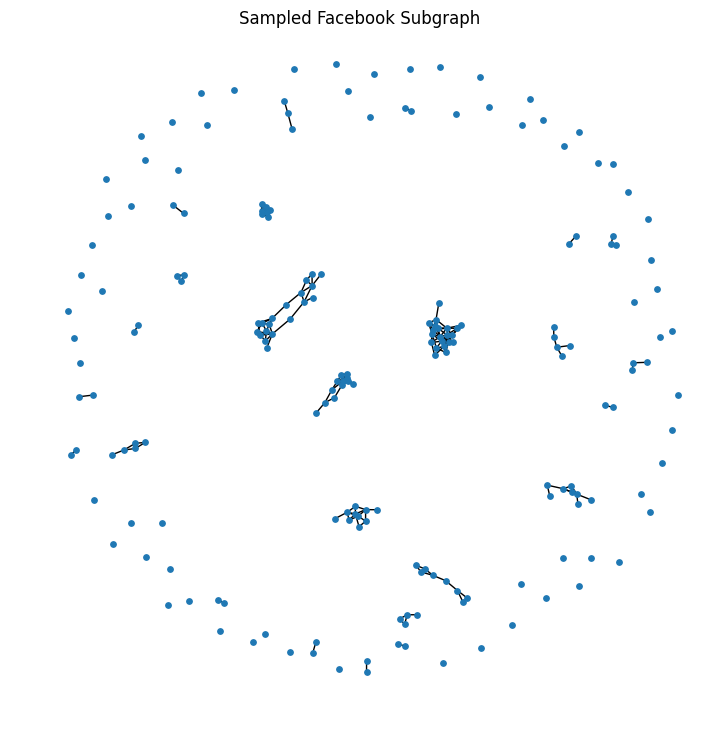

In [ ]:
sample_nodes = random.sample(list(G.nodes()), 200)
SG = G.subgraph(sample_nodes)

pos = nx.spring_layout(SG, seed=42)
nx.draw(SG, pos, node_size=15)
plt.title("Sampled Facebook Subgraph")
plt.show()

### Task 1: Graph information

In [ ]:
# number of nodes
num_nodes = G.number_of_nodes()
print("Number of nodes:", num_nodes)

# number of edges
num_edges = G.number_of_edges()
print("Number of edges:", num_edges)

# average degree
avg_degree = 2 * num_edges / num_nodes
print("Average degree:", avg_degree)

Number of nodes: 4039
Number of edges: 88234
Average degree: 43.69101262688784


###  Task 2: Network density
Network density:  measures how many connections exist compared to how many could possibly exist.
In this exercise you will
- compute and interpret the density of a Facebook social network graph.



In [ ]:
n = G.number_of_nodes()
m = G.number_of_edges()

# maximum possible number of edges in this network
max_edges = n * (n - 1) / 2
print("Maximum possible edges:", int(max_edges))

# percentage of possible edges actually exist
density = m / max_edges
print("Network density:", density)

print("Percentage of possible edges that exist:",
      100 * density, "%")

Maximum possible edges: 8154741
Network density: 0.010819963503439287
Percentage of possible edges that exist: 1.0819963503439287 %


**What does this suggest about how people form friendships on Facebook?**

- Answer here:  The network density is very low, meaning that only a small fraction of all possible friendships actually exist. This suggest that Facebook friendship formation is highly selective. Even though users are connected in a large network, individuals only form connections with a relatively small subset of all possible users. This reflects real-world social behavior, as people have limited social circles rather than connecting with everyone in the network.

## Degree Distribution Analysis

### Introduction: Power-Law Degree Distribution

In real networks, connections are not evenly distributed and most nodes have only a few connections, while a small number of nodes have a very large number of connections.

This pattern is known as a **power-law distribution**, and it leads to:

- Many users with few friends,
- A few users with extremely many friends.

Nodes with unusually high numbers of connections are often called **hubs**, and they play an important role in maintaining network connectivity.

Mathematically, the probability that a node has degree \(k\) follows:

$
P(k) \propto k^{-\alpha}
$

where:
- $k$ is the node degree,
- $\alpha$ is a positive constant controlling how quickly the distribution decays.

### Task 3:
**Does this network follow: power-law distribution, or normal distribution?**

Total degree entries: 4039


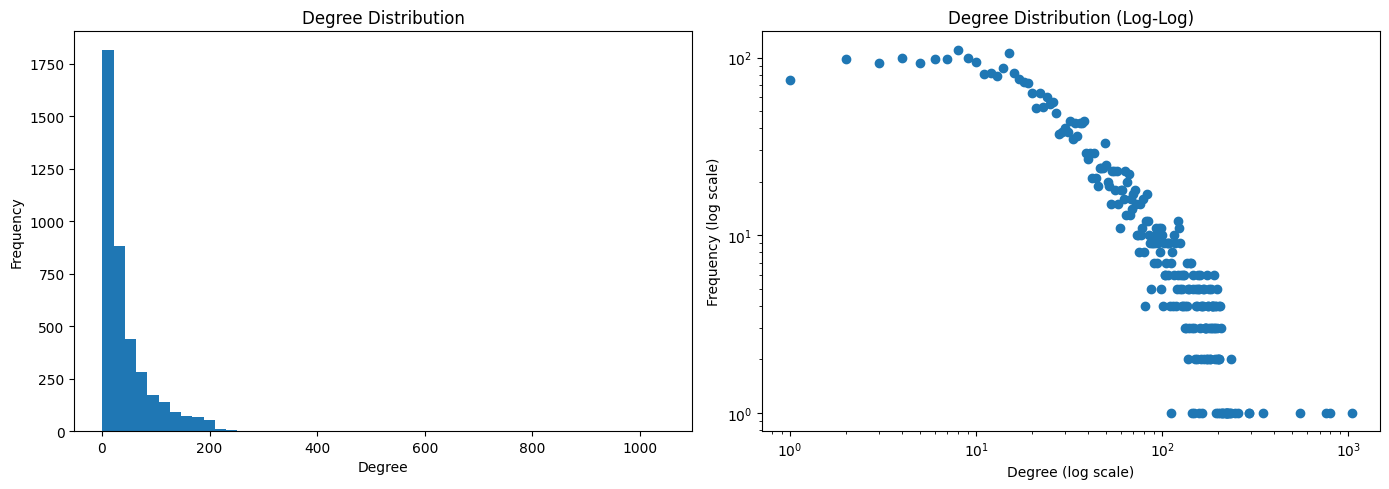

Minimum degree: 1
Maximum degree: 1045
Median degree: 25.0
Mean degree: 43.69101262688784
Standard deviation: 52.41411556737521


In [ ]:
## degree distribution
degrees = [deg for node, deg in G.degree()]

print("Total degree entries:", len(degrees))

## degree distribution visual**
plt.figure(figsize=(14, 5))

# histogram
plt.subplot(1, 2, 1)

plt.hist(degrees, bins=50)
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.title('Degree Distribution')

# log-log plot
plt.subplot(1, 2, 2)

unique_degrees, counts = np.unique(degrees, return_counts=True)

plt.scatter(unique_degrees, counts)
plt.xscale('log')
plt.yscale('log')

plt.xlabel('Degree (log scale)')
plt.ylabel('Frequency (log scale)')
plt.title('Degree Distribution (Log-Log)')

plt.tight_layout()
plt.show()

## observations**
## min, max, median, mean, and standard deviation of degrees
print("Minimum degree:", np.min(degrees))
print("Maximum degree:", np.max(degrees))
print("Median degree:", np.median(degrees))
print("Mean degree:", np.mean(degrees))
print("Standard deviation:", np.std(degrees))


**Q1. Log-log plot**: Does it approximate a straight line, suggesting power-law behavior?  



- The log-log plot approximately follows a linear downward trend in the tail region, which suggests power-law behavior. The network does not resemble a normal distribution because it is heavily right-skewed. Instead, it exhibits a scale-free structure with many low-degree nodes and a few extremely high-degree hubs.

**Q2.High-degree nodes (hubs)**: What roles do these nodes play in a social network?  

- High-degree nodes act as hubs that maintain overall connectivity of the network. They facilitate rapid information diffusion and play a central role in spreading content across the network. Because they connect to many users, their removal could significantly fragment the network and reduce global connectivity.

##  Centrality Analysis

Centrality measures identify the most "important" nodes in different ways.

### Task 4: Compute centralities

In [ ]:
## computer degree centrality
deg_cent = nx.degree_centrality(G)

## computer between centrality
bet_cent = nx.betweenness_centrality(G)

## computer closeness centrality
close_cent = nx.closeness_centrality(G)

print("Centralities computed.")

## top k central nodes
def top_k_nodes(centrality_dict, k=10):
    return sorted(centrality_dict.items(),
                  key=lambda x: x[1],
                  reverse=True)[:k]

## top k for degree centrality
k = 10

top_deg = top_k_nodes(deg_cent, k)
print("Top 10 Degree Centrality:")
print(top_deg)

## top k for Betweenness centrality
top_bet = top_k_nodes(bet_cent, k)
print("\nTop 10 Betweenness Centrality:")
print(top_bet)

## top k for Closeness centrality
top_close = top_k_nodes(close_cent, k)
print("\nTop 10 Closeness Centrality:")
print(top_close)

Centralities computed.
Top 10 Degree Centrality:
[(107, 0.258791480931154), (1684, 0.1961367013372957), (1912, 0.18697374938088163), (3437, 0.13546310054482416), (0, 0.08593363051015354), (2543, 0.07280832095096582), (2347, 0.07206537890044576), (1888, 0.0629024269440317), (1800, 0.06067360079247152), (1663, 0.058197127290737984)]

Top 10 Betweenness Centrality:
[(107, 0.4805180785560152), (1684, 0.3377974497301992), (3437, 0.23611535735892905), (1912, 0.2292953395868782), (1085, 0.14901509211665306), (0, 0.14630592147442917), (698, 0.11533045020560802), (567, 0.09631033121856215), (58, 0.08436020590796486), (428, 0.06430906239323866)]

Top 10 Closeness Centrality:
[(107, 0.45969945355191255), (58, 0.3974018305284913), (428, 0.3948371956585509), (563, 0.3939127889961955), (1684, 0.39360561458231796), (171, 0.37049270575282134), (348, 0.36991572004397216), (483, 0.3698479575013739), (414, 0.3695433330282786), (376, 0.36655773420479304)]


### Task 5: Centrality Comparison
Use k = 10

In [ ]:
## overlap of degree and betweenness for top k
deg_set = set(node for node, _ in top_deg)
bet_set = set(node for node, _ in top_bet)
print("Overlap Degree & Betweenness:", deg_set & bet_set)

## overlap of degree and Closeness for top k
close_set = set(node for node, _ in top_close)
print("Overlap Degree & Closeness:", deg_set & close_set)

## overlap of Betweenness and Closeness for top k
print("Overlap Betweenness & Closeness:", bet_set & close_set)

## overlap among all top k
print("Overlap All Three:", deg_set & bet_set & close_set)

Overlap Degree & Betweenness: {0, 107, 3437, 1684, 1912}
Overlap Degree & Closeness: {107, 1684}
Overlap Betweenness & Closeness: {1684, 58, 107, 428}
Overlap All Three: {107, 1684}


**Q1:** What does the overlap between top-k nodes across different centrality measures tell you about the network structure?  




- The overlap between top-k nodes across centrality measures shows whether the same nodes are important in different structural senses. A strong degree-betweenness overlap indicates that some hubs also act as bridges that connect different parts of the network. A smaller overlap with closeness suggests that many hubs are not globally central by distance, while a few nodes are consistently central across multiple measures, indicating a core backbone of influenctial nodes.

**Q2:** How would you interpret nodes that appear in **all three top-k sets**?  


- Nodes appearing in all three top-k sets are structrually dominant. They are highly connected, they lie on many shortest paths, and are globally close to most nodes. Thes nodes likely form part of the network's core and are specially important for connectivity and information flow.


## Community Detection

Communities are densely connected groups of nodes with sparser connections between groups.

### Task 6
1. Show number of communities & the size.
2. Visualize top 5 community in the network

In [ ]:
# TODO Part 1: Detect communities using
# Greedy Modularity Optimization

from networkx.algorithms.community import greedy_modularity_communities

# compute communities
communities_greedy = list(greedy_modularity_communities(G))

print("Greedy Modularity: number of communities =", len(communities_greedy))

# compute community sizes
community_sizes_greedy = sorted([len(c) for c in communities_greedy], reverse=True)

print("Top 10 community sizes (Greedy):", community_sizes_greedy[:10])
print("Smallest community size (Greedy):", community_sizes_greedy[-1])
print("Total nodes accounted for:", sum(community_sizes_greedy))

Greedy Modularity: number of communities = 13
Top 10 community sizes (Greedy): [983, 815, 548, 543, 372, 219, 208, 206, 59, 37]
Smallest community size (Greedy): 6
Total nodes accounted for: 4039


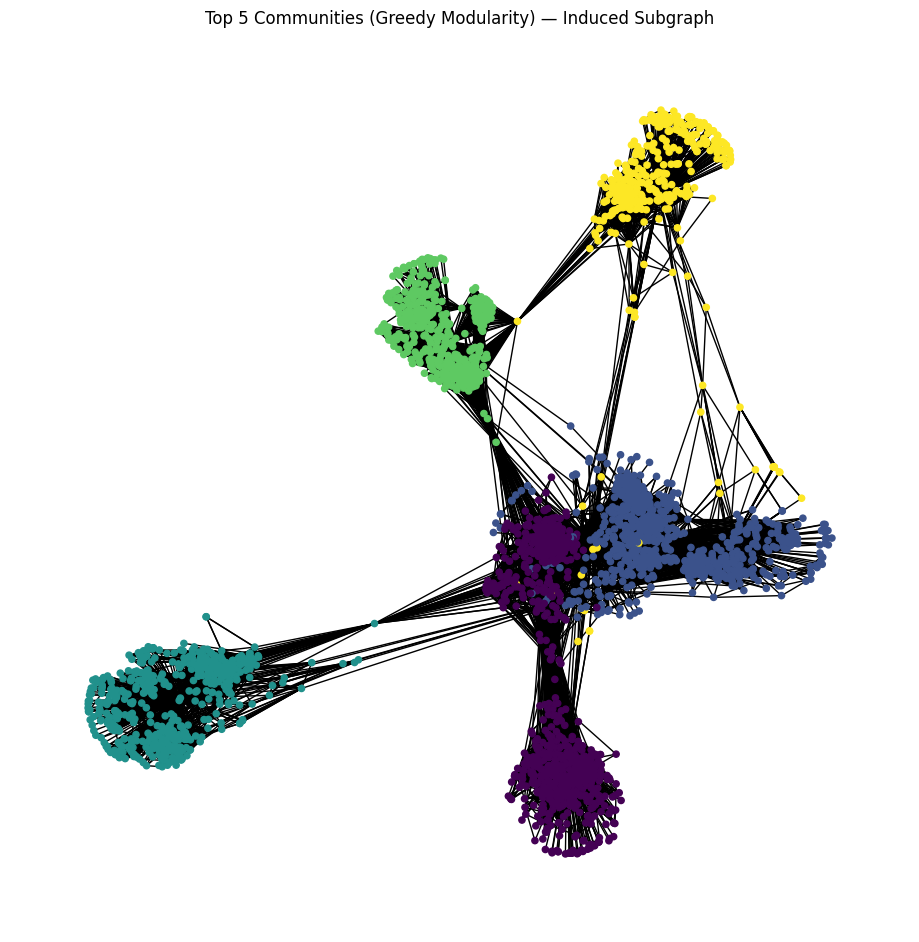

In [ ]:
# top communities visual
k = 5

# take top-k communities by size
top_comms = sorted(communities_greedy, key=len, reverse=True)[:k]

# induced subgraph on nodes from the top k communities
top_nodes = set().union(*top_comms)
H = G.subgraph(top_nodes)

# map each node -> community index
node_to_comm = {}
for i, comm in enumerate(top_comms):
    for node in comm:
        node_to_comm[node] = i

node_colors = [node_to_comm[node] for node in H.nodes()]

plt.figure(figsize=(9, 9))
pos = nx.spring_layout(H, seed=42)
nx.draw(H, pos, node_size=20, node_color=node_colors, with_labels=False)
plt.title("Top 5 Communities (Greedy Modularity) — Induced Subgraph")
plt.show()

In [ ]:
# detect communities using
# Girvan–Newman algorithm
from networkx.algorithms.community import girvan_newman

# Girvan–Newman is very slow on large networks
# sampled subgraph (like the lab using small graphs)
sample_n = 1000
sample_nodes = random.sample(list(G.nodes()), sample_n)
G_gn = G.subgraph(sample_nodes).copy()

gn_gen = girvan_newman(G_gn)

communities_gn = next(gn_gen)
communities_gn = [set(c) for c in communities_gn]

print("Girvan–Newman (sampled): number of communities (first split) =", len(communities_gn))

community_sizes_gn = sorted([len(c) for c in communities_gn], reverse=True)
print("Community sizes (GN first split, sampled):", community_sizes_gn)
print("Total nodes accounted for:", sum(community_sizes_gn))

Girvan–Newman (sampled): number of communities (first split) = 118
Community sizes (GN first split, sampled): [313, 224, 159, 92, 39, 9, 8, 8, 6, 5, 4, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Total nodes accounted for: 1000


**Q1.** Which method produces more communities, and why might this occur?











- Greedy modularity produces more communities than Girvan–Newman. It directly optimizes modularity and tends to partition the network into multiple densely connected groups. Girvan–Newman is hierarchical, it progressively removes edges with high betweenness, so early outputs produce only a small number of coarse communities unless we iterate many splits. (Here GN was run on a sampled subgraph because it is too slow on the full network.)

**Q2.** How do the community sizes differ between the methods?



- Greedy modularity produced several medium-to-large communities plus smaller ones, indicating multiple clusters. Girvan–Newman’s first split typically yields two very large communities because it begins with a coarse partition and only produces finer sub-communities after many iterations.

**Q3.** Which algorithm is more practical for large networks?




- Greedy modularity is more practical for large networks because it is much faster and returns a full partition directly. Girvan–Newman is computationally expensive since it repeatedly recomputes edge betweenness during edge removals, making it less scalable.

### Task 7: Community Structure Analysis


In [ ]:
# calculate modularity score
from networkx.algorithms.community.quality import modularity

mod_score = modularity(G, communities_greedy)
print("Modularity (Greedy Modularity communities):", mod_score)

Modularity (Greedy Modularity communities): 0.7773775199040279


Q. What does the modularity score indicate about the network structure?



- The modularity score of 0.777 indicates strong community structure in the Facebook network. This suggests that users form tightly connected groups with relatively fewer connections between groups. Such a high modularity value reflects well-defined clusters, which is consistent with how social networks naturally organize around shared affiliations such as schools, workplaces, and social circles.

### Task 8: Bridge Nodes and Inter-Community Connectivity

In [ ]:
# TODO: Compute cross-community degree

node_to_comm = {}
for i, comm in enumerate(communities_greedy):
    for node in comm:
        node_to_comm[node] = i

cross_degree = {}

for node in G.nodes():
    current_comm = node_to_comm[node]
    cross_count = 0

    for neighbor in G.neighbors(node):
        if node_to_comm[neighbor] != current_comm:
            cross_count += 1

    cross_degree[node] = cross_count

#TODO: Find Top 10 bridge nodes
K = 10

top_bridge_nodes = sorted(cross_degree.items(),
                          key=lambda x: x[1],
                          reverse=True)[:K]

print("Top Bridge Nodes (by cross-community degree):")
for node, cross in top_bridge_nodes:
    print(node, "->", cross)

# TODO: Display community exposure of bridge nodes
# Hint: For each of the top bridge nodes:
#        1. Compute the total number of connections (degree).
#        2. Count how many of those connections go to OTHER communities.
#        3. Report the percentage of cross-community connections.

print("\nCommunity Exposure Details:")

for node, cross in top_bridge_nodes:
    total_degree = G.degree(node)
    percentage = (cross / total_degree) * 100 if total_degree > 0 else 0

    print(f"Node {node}:")
    print(f"  Total Degree: {total_degree}")
    print(f"  Cross-Community Degree: {cross}")
    print(f"  Percentage Cross-Community: {percentage:.2f}%\n")

Top Bridge Nodes (by cross-community degree):
107 -> 507
1684 -> 255
1912 -> 213
2347 -> 173
2543 -> 155
2468 -> 138
136 -> 111
1941 -> 101
1334 -> 78
2478 -> 65

Community Exposure Details:
Node 107:
  Total Degree: 1045
  Cross-Community Degree: 507
  Percentage Cross-Community: 48.52%

Node 1684:
  Total Degree: 792
  Cross-Community Degree: 255
  Percentage Cross-Community: 32.20%

Node 1912:
  Total Degree: 755
  Cross-Community Degree: 213
  Percentage Cross-Community: 28.21%

Node 2347:
  Total Degree: 291
  Cross-Community Degree: 173
  Percentage Cross-Community: 59.45%

Node 2543:
  Total Degree: 294
  Cross-Community Degree: 155
  Percentage Cross-Community: 52.72%

Node 2468:
  Total Degree: 177
  Cross-Community Degree: 138
  Percentage Cross-Community: 77.97%

Node 136:
  Total Degree: 133
  Cross-Community Degree: 111
  Percentage Cross-Community: 83.46%

Node 1941:
  Total Degree: 223
  Cross-Community Degree: 101
  Percentage Cross-Community: 45.29%

Node 1334:
  Total

Q. Why are nodes that connect different communities important?




- Bridge nodes play a crucial role in maintaining connectivity between otherwise densely clustered communities. While some bridge nodes are high-degree hubs with many internal and external connections, others have a large proportion of their edges linking different communities. These nodes facilitate information flow across groups and prevent the network from fragmenting into isolated clusters. In social networks, such nodes often represent individuals who connect multiple social circles, such as different schools, workplaces, or interest groups.


## Link Prediction

Can we predict missing or future friendships?

In [ ]:
## Manually deleting some links
G_lp = G.copy()

all_edges = list(G_lp.edges())
random.shuffle(all_edges)

remove_count = int(0.01 * len(all_edges))
removed_edges = all_edges[:remove_count]
G_lp.remove_edges_from(removed_edges)

removed_set = set(tuple(sorted(e)) for e in removed_edges)

print(f"Removed {remove_count} edges for testing")
print(f"Remaining edges: {G_lp.number_of_edges()}")

Removed 882 edges for testing
Remaining edges: 87352


###  Link prediction methods

1. **Jaccard Coefficient**  
   Measures similarity between two nodes based on the fraction of shared neighbors:

   $$
   J(u,v) = \frac{|N(u) \cap N(v)|}{|N(u) \cup N(v)|}
   $$

2. **Adamic-Adar Index**  
   Similar to Jaccard, but gives more weight to shared neighbors with fewer connections:

   $$
   AA(u,v) = \sum_{w \in N(u) \cap N(v)} \frac{1}{\log(\mathrm{deg}(w))}
   $$



In [ ]:
# Predict edges using Jaccard
# Generate predictions
pred_j = nx.jaccard_coefficient(G_lp)

# Keep top 5000 predictions
pred_j = sorted(pred_j, key=lambda x: x[2], reverse=True)[:5000]

# Count how many predicted edges were actually removed
correct_j = sum(
    1 for u, v, _ in pred_j
    if tuple(sorted((u, v))) in removed_set
)

#Predict edges using Adamic-Adar
pred_a = nx.adamic_adar_index(G_lp)
pred_a = sorted(pred_a, key=lambda x: x[2], reverse=True)[:5000]

correct_a = sum(
    1 for u, v, _ in pred_a
    if tuple(sorted((u, v))) in removed_set
)

# Display results
print(f"Jaccard: Recovered {correct_j}/{remove_count} edges "
      f"({100*correct_j/remove_count:.1f}%)")

print(f"Adamic-Adar: Recovered {correct_a}/{remove_count} edges "
      f"({100*correct_a/remove_count:.1f}%)")


Jaccard: Recovered 226/882 edges (25.6%)
Adamic-Adar: Recovered 241/882 edges (27.3%)


Q1. Which method recovered more of the removed edges? Why do you think that is?




- Adamic-Adar recovered slightly more of the removed edges compared to Jaccard. This is likely because Adamic-Adar assigns greater weight to shared neighbors with lower degrees, which are more informative in social networks. In scale-free networks like Facebook, many nodes connect through hubs. Jaccard penalizes high-degree nodes due to its normalization, whereas Adamic-Adar better captures meaningful shared connections.

Q2. Why might Jaccard perform worse in some networks?





- Jaccard may perform worse in networks with highly skewed degree distributions because it normalizes by the total number of neighbors. In networks with hubs, the union of neighbors can be very large, reducing the similarity score even when two nodes share meaningful connections. This makes Jaccard less effective in scale-free or hub-dominated networks.


Q3. How does the number of shared neighbors influence both methods?



- Both methods increase similarity as the number of shared neighbors increases. However, Jaccard treats all shared neighbors equally, while Adamic-Adar weights shared neighbors inversely by their degree. As a result, shared connections to low-degree nodes contribute more to the Adamic-Adar score, making it more sensitive to structurally meaningful relationships.